In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA_PATH = (
    PROJECT_ROOT / "data" / "processed" / "processed_train.csv"
)

df = pd.read_csv(
    PROCESSED_DATA_PATH,
    parse_dates=["date"],
)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

df.head()

C:\Users\Hemasri Reddy\AppData\Local\Temp\ipykernel_25836\1738286170.py:12: DtypeWarning: Columns (0: holiday_type, 1: holiday_locale, 2: holiday_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Rows: 3,000,888
Columns: 17
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions,dcoilwtico,is_holiday,holiday_type,holiday_locale,holiday_name,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,93.14,1.0,Holiday,National,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN,93.14,1.0,Holiday,National,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN,93.14,1.0,Holiday,National,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,NaN,93.14,1.0,Holiday,National,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,NaN,93.14,1.0,Holiday,National,Primer dia del ano,False


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 17 columns):
 #   Column          Dtype         
---  ------          -----         
 0   id              int64         
 1   date            datetime64[us]
 2   store_nbr       int64         
 3   family          str           
 4   sales           float64       
 5   onpromotion     int64         
 6   city            str           
 7   state           str           
 8   type            str           
 9   cluster         int64         
 10  transactions    float64       
 11  dcoilwtico      float64       
 12  is_holiday      float64       
 13  holiday_type    str           
 14  holiday_locale  str           
 15  holiday_name    str           
 16  transferred     bool          
dtypes: bool(1), datetime64[us](1), float64(4), int64(4), str(7)
memory usage: 369.2 MB


In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,3000888.0,NaN,NaN,NaN,1500443.5,0.0,750221.75,1500443.5,2250665.25,3000887.0,866281.891642
date,3000888,NaN,NaN,NaN,2015-04-24 08:27:04.703088,2013-01-01 00:00:00,2014-02-26 18:00:00,2015-04-24 12:00:00,2016-06-19 06:00:00,2017-08-15 00:00:00,NaN
store_nbr,3000888.0,NaN,NaN,NaN,27.5,1.0,14.0,27.5,41.0,54.0,15.585787
family,3000888,33,AUTOMOTIVE,90936,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sales,3000888.0,NaN,NaN,NaN,357.775749,0.0,0.0,11.0,195.84725,124717.0,1101.997721
onpromotion,3000888.0,NaN,NaN,NaN,2.60277,0.0,0.0,0.0,0.0,741.0,12.218882
city,3000888,22,Quito,1000296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,3000888,16,Pichincha,1055868,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,3000888,5,D,1000296,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cluster,3000888.0,NaN,NaN,NaN,8.481481,1.0,4.0,8.5,13.0,17.0,4.649735


In [4]:
missing_transactions = df[df["transactions"].isna()]

print(
    f"Rows with missing transactions: "
    f"{len(missing_transactions):,}"
)

print(
    f"Percentage of rows: "
    f"{len(missing_transactions) / len(df) * 100:.2f}%"
)

print(
    f"Unique store-date combinations affected: "
    f"{missing_transactions[['date', 'store_nbr']].drop_duplicates().shape[0]:,}"
)

print(
    f"Stores affected: "
    f"{missing_transactions['store_nbr'].nunique()}"
)

Rows with missing transactions: 245,784
Percentage of rows: 8.19%
Unique store-date combinations affected: 7,448
Stores affected: 54


In [5]:
daily_sales = (
    df.groupby("date", as_index=False)["sales"]
    .sum()
)

daily_sales.head()

,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


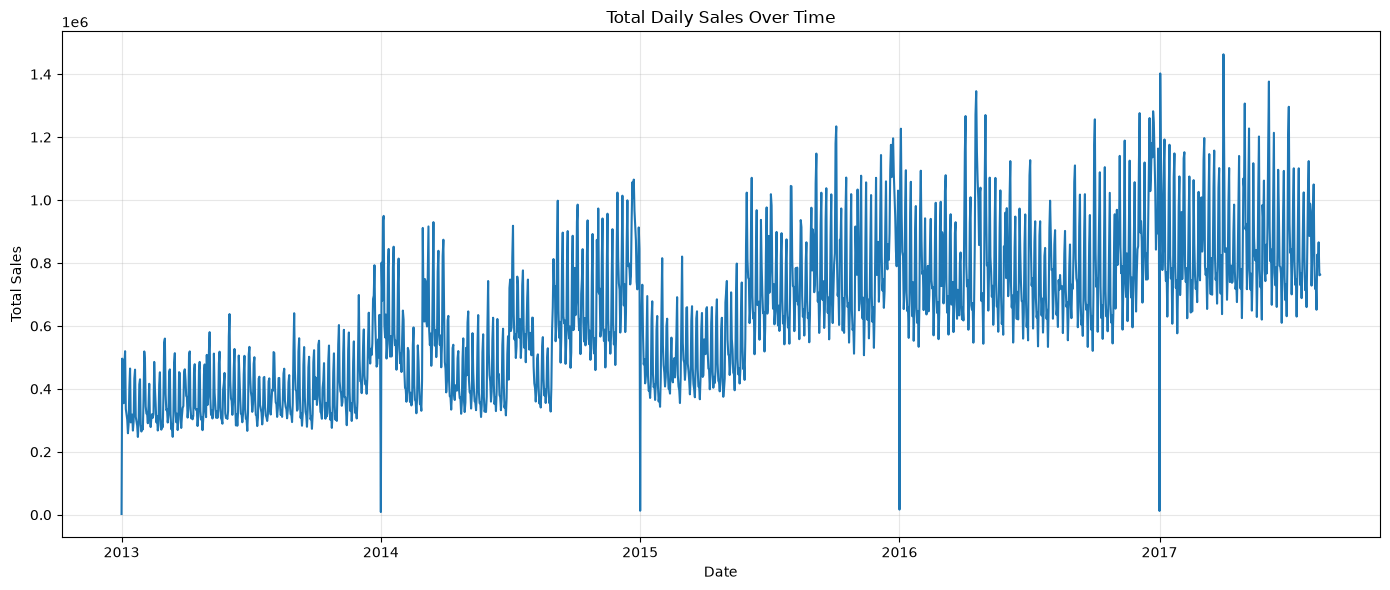

In [6]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"],
)

plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

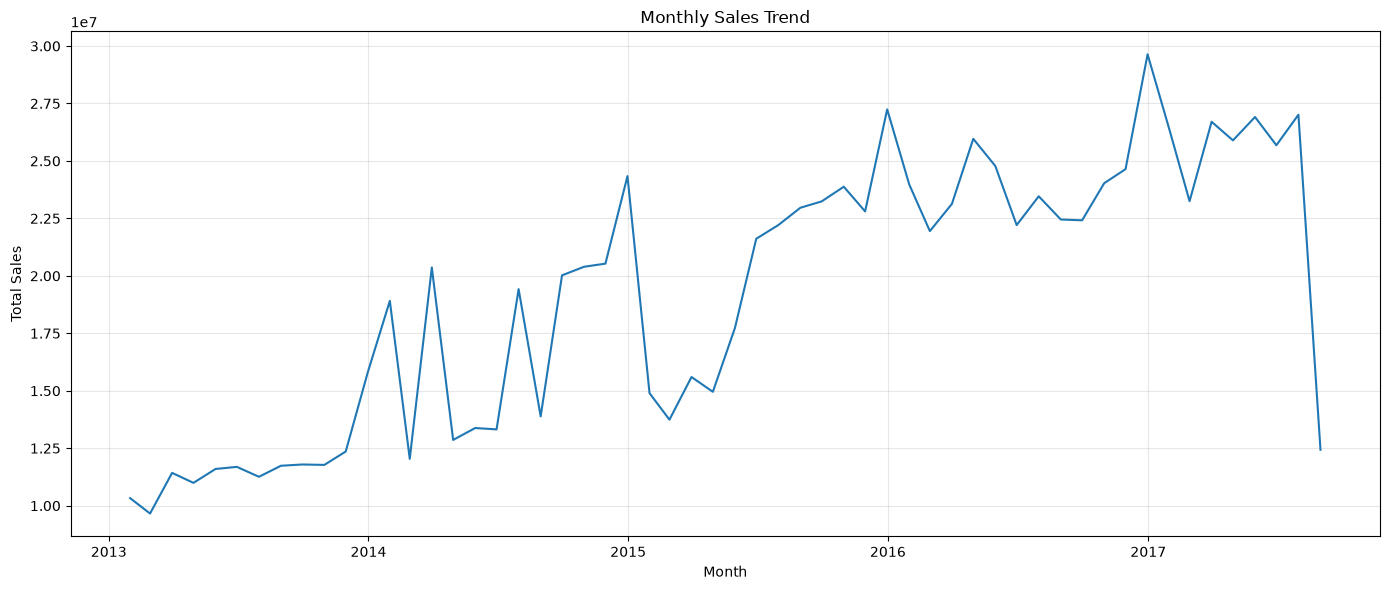

In [7]:
monthly_sales = (
    df.set_index("date")
    .resample("ME")["sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["date"],
    monthly_sales["sales"],
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
family_sales = (
    df.groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
)

family_sales.head(10)

family
GROCERY I        3.434627e+08
BEVERAGES        2.169545e+08
PRODUCE          1.227047e+08
CLEANING         9.752129e+07
DAIRY            6.448771e+07
BREAD/BAKERY     4.213395e+07
POULTRY          3.187600e+07
MEATS            3.108647e+07
PERSONAL CARE    2.459205e+07
DELI             2.411032e+07
Name: sales, dtype: float64

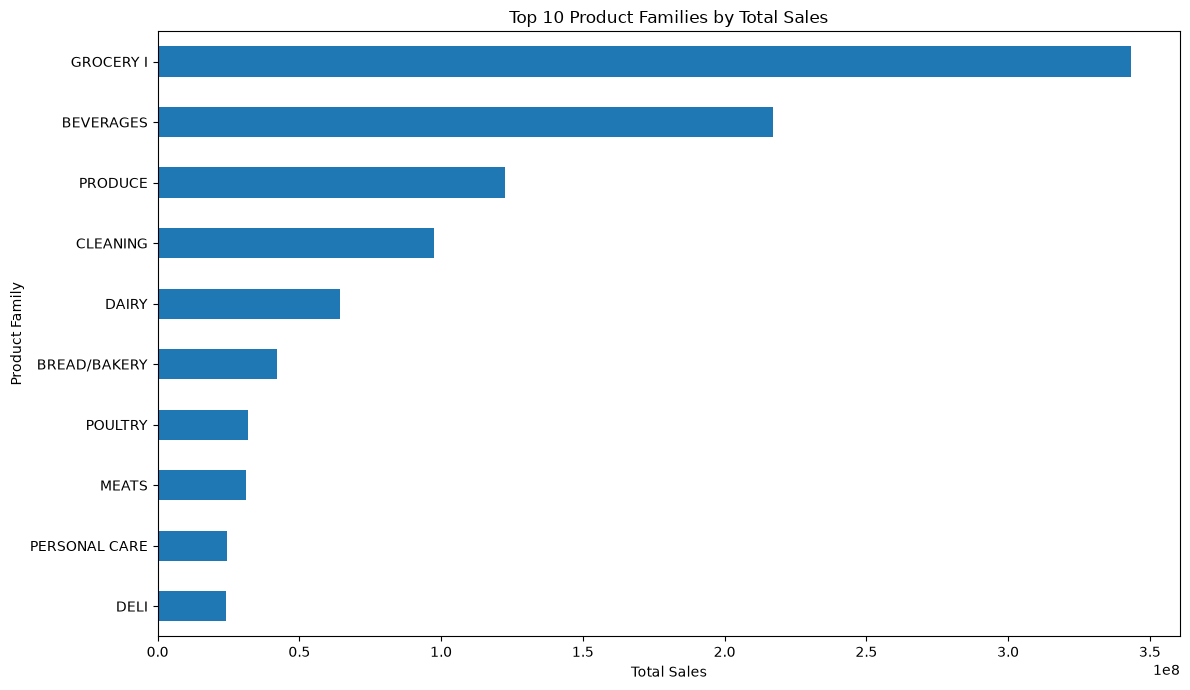

In [9]:
plt.figure(figsize=(12, 7))

family_sales.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Product Families by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product Family")
plt.tight_layout()
plt.show()

In [10]:
state_sales = (
    df.groupby("state")["sales"]
    .sum()
    .sort_values(ascending=False)
)

state_sales

state
Pichincha                         5.850674e+08
Guayas                            1.651544e+08
Azuay                             4.916860e+07
Tungurahua                        4.030440e+07
Santo Domingo de los Tsachilas    3.583432e+07
El Oro                            3.338680e+07
Los Rios                          3.192537e+07
Manabi                            2.496982e+07
Cotopaxi                          2.118226e+07
Loja                              1.886000e+07
Esmeraldas                        1.639169e+07
Bolivar                           1.304951e+07
Imbabura                          1.145127e+07
Santa Elena                       1.142100e+07
Chimborazo                        1.138792e+07
Pastaza                           4.090202e+06
Name: sales, dtype: float64

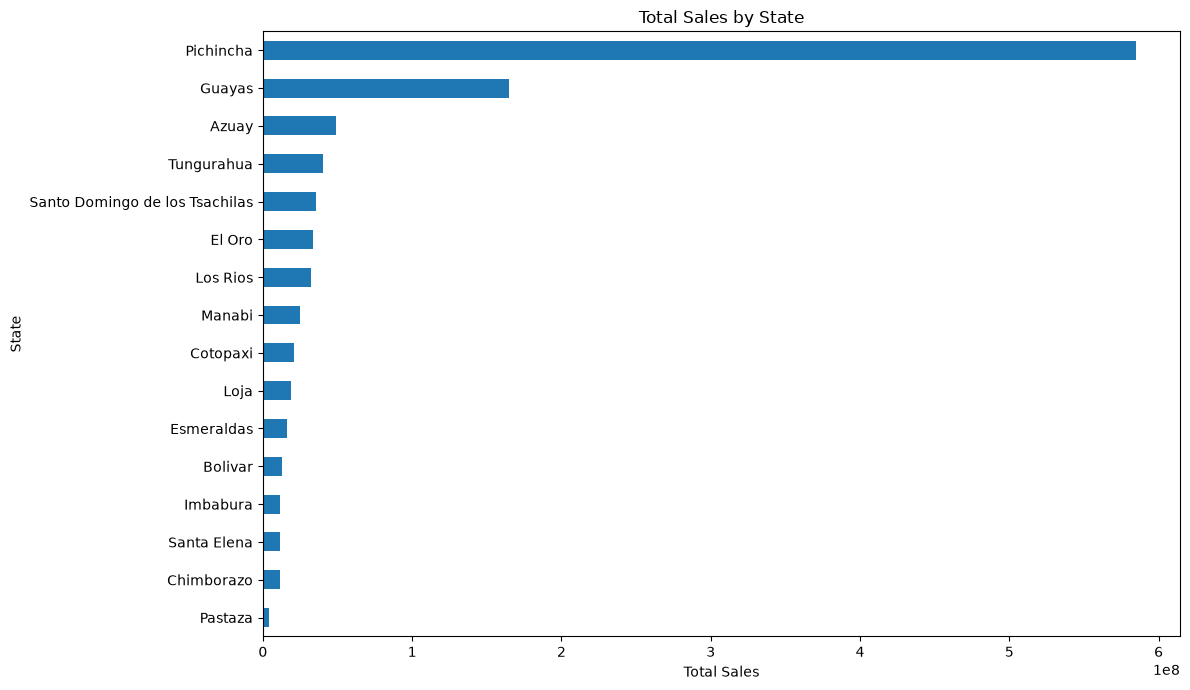

In [11]:
plt.figure(figsize=(12, 7))

state_sales.sort_values().plot(
    kind="barh"
)

plt.title("Total Sales by State")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [12]:
df["day_of_week"] = df["date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_sales = (
    df.groupby("day_of_week")["sales"]
    .mean()
    .reindex(weekday_order)
)

weekday_sales

day_of_week
Monday       346.544732
Tuesday      319.823843
Wednesday    332.909401
Thursday     283.540517
Friday       325.238138
Saturday     433.336472
Sunday       463.085366
Name: sales, dtype: float64

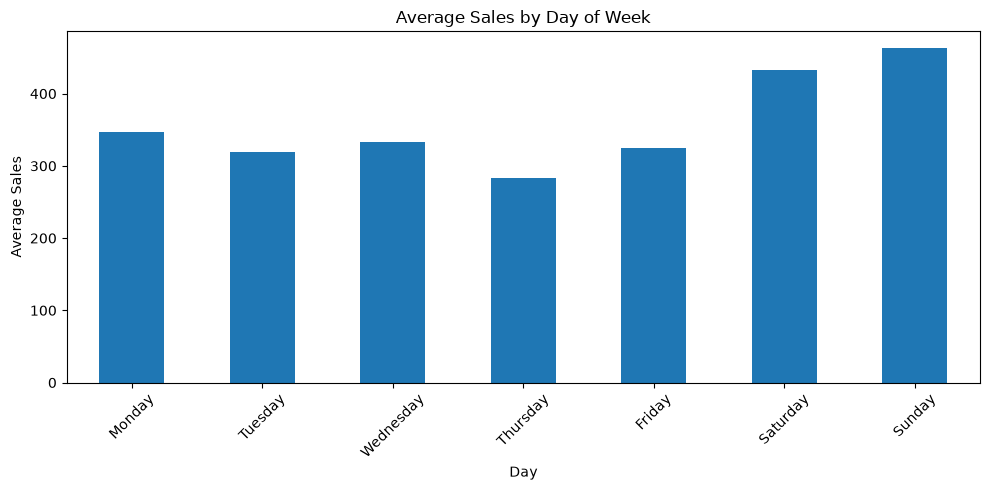

In [13]:
plt.figure(figsize=(10, 5))

weekday_sales.plot(
    kind="bar"
)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
df["has_promotion"] = df["onpromotion"] > 0

promotion_sales = (
    df.groupby("has_promotion")["sales"]
    .mean()
)

promotion_sales

has_promotion
False     158.246681
True     1137.693730
Name: sales, dtype: float64

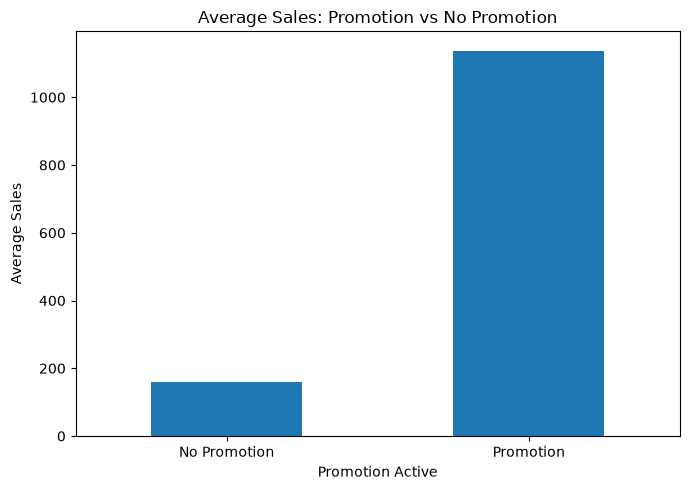

In [15]:
plt.figure(figsize=(7, 5))

promotion_sales.plot(
    kind="bar"
)

plt.title("Average Sales: Promotion vs No Promotion")
plt.xlabel("Promotion Active")
plt.ylabel("Average Sales")
plt.xticks(
    ticks=[0, 1],
    labels=["No Promotion", "Promotion"],
    rotation=0,
)
plt.tight_layout()
plt.show()

In [16]:
holiday_sales = (
    df.groupby("is_holiday")["sales"]
    .mean()
)

holiday_sales

is_holiday
0.0    352.159181
1.0    389.692123
Name: sales, dtype: float64

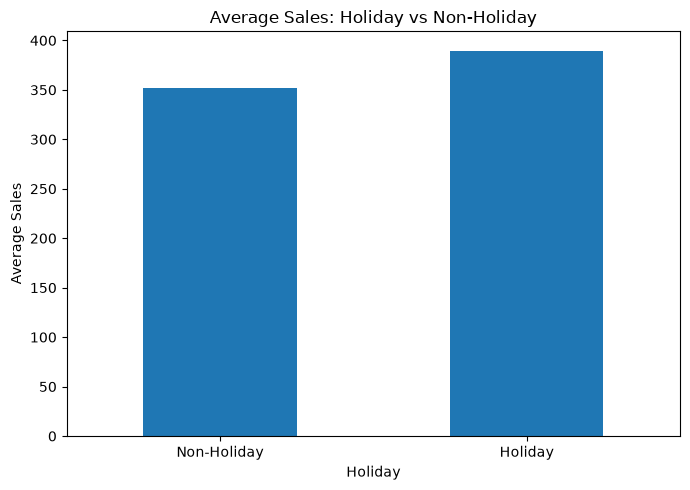

In [17]:
plt.figure(figsize=(7, 5))

holiday_sales.plot(
    kind="bar"
)

plt.title("Average Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday")
plt.ylabel("Average Sales")
plt.xticks(
    ticks=[0, 1],
    labels=["Non-Holiday", "Holiday"],
    rotation=0,
)
plt.tight_layout()
plt.show()

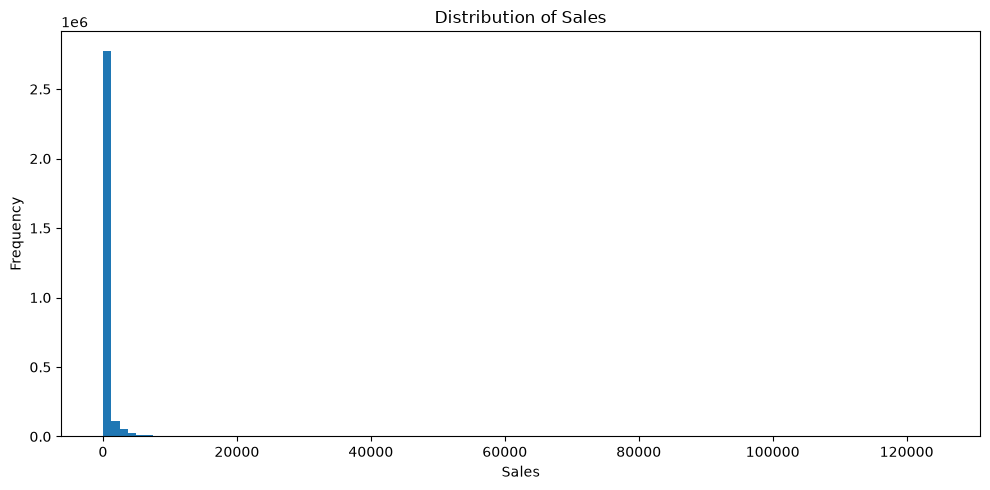

In [18]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["sales"],
    bins=100,
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [19]:
df["sales"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
)

0.500       11.000000
0.750      195.847250
0.900      867.000000
0.950     1965.000000
0.990     5507.000000
0.999    12076.225548
Name: sales, dtype: float64

In [20]:
featured_df = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "featured_train.csv",
    parse_dates=["date"],
)

example = (
    featured_df[
        (featured_df["store_nbr"] == 1)
        & (featured_df["family"] == "BEVERAGES")
    ]
    .sort_values("date")
)

example[
    [
        "date",
        "sales",
        "sales_lag_1",
        "sales_lag_7",
        "rolling_mean_7",
    ]
].head(12)

,date,sales,sales_lag_1,sales_lag_7,rolling_mean_7
5052,2013-01-01,0.0,NaN,NaN,NaN
5053,2013-01-02,1091.0,0.0,NaN,NaN
5054,2013-01-03,919.0,1091.0,NaN,NaN
5055,2013-01-04,953.0,919.0,NaN,NaN
5056,2013-01-05,1160.0,953.0,NaN,NaN
5057,2013-01-06,407.0,1160.0,NaN,NaN
5058,2013-01-07,1158.0,407.0,NaN,NaN
5059,2013-01-08,1029.0,1158.0,0.0,812.571429
5060,2013-01-09,1186.0,1029.0,1091.0,959.571429
5061,2013-01-10,847.0,1186.0,919.0,973.142857
